D:\Anaconda\envs\new\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Device: cuda
Font stack: ['Malgun Gothic', 'Microsoft YaHei', 'SimHei', 'SimSun'] ...

===== 1. DATA LOADING =====
Loading Korean NSMC ...
Loading Chinese Douban ...
  Douban candidate pool: 1486305 rows across 28 movies
  After multi-movie stratified sampling: 2000 rows covering 28 movies
Loading English IMDB ...

Total samples: 6000
Distribution by language x label:
label     negative  positive
language                    
en            1000      1000
ko            1000      1000
zh            1000      1000


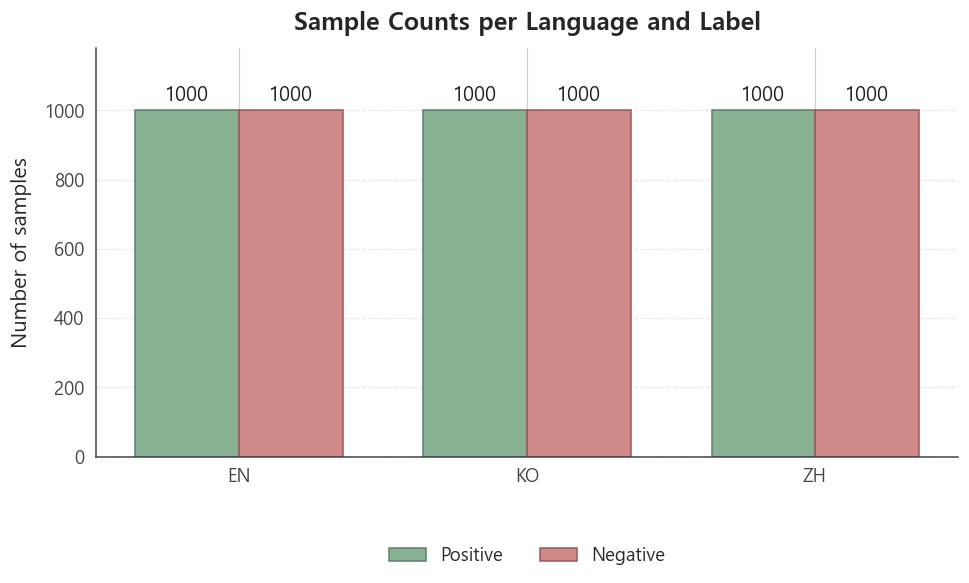


===== 2. TOKENIZATION =====


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Samual\AppData\Local\Temp\jieba.cache
Loading model cost 0.322 seconds.
Prefix dict has been built successfully.
Token indices sequence length is longer than the specified maximum sequence length for this model (1435 > 512). Running this sequence through the model will result in indexing errors



Tokenization statistics:
language baseline_name  base_avg_tokens  bpe_avg_tokens  base_token_char_len  bpe_token_char_len  base_compression  bpe_compression  base_oov  bpe_oov  bpe_subword_ratio
      ko          Kiwi          20.5745         25.0850             1.669324            1.286704          0.560115         0.693247  0.084887 0.016863           0.574846
      zh         Jieba          24.6955         38.5655             1.644227            1.072594          0.624159         0.972206  0.122413 0.009309           0.003176
      en    Whitespace         234.6795        330.9055             4.602974            3.273437          0.179415         0.252159  0.078455 0.000151           0.144677


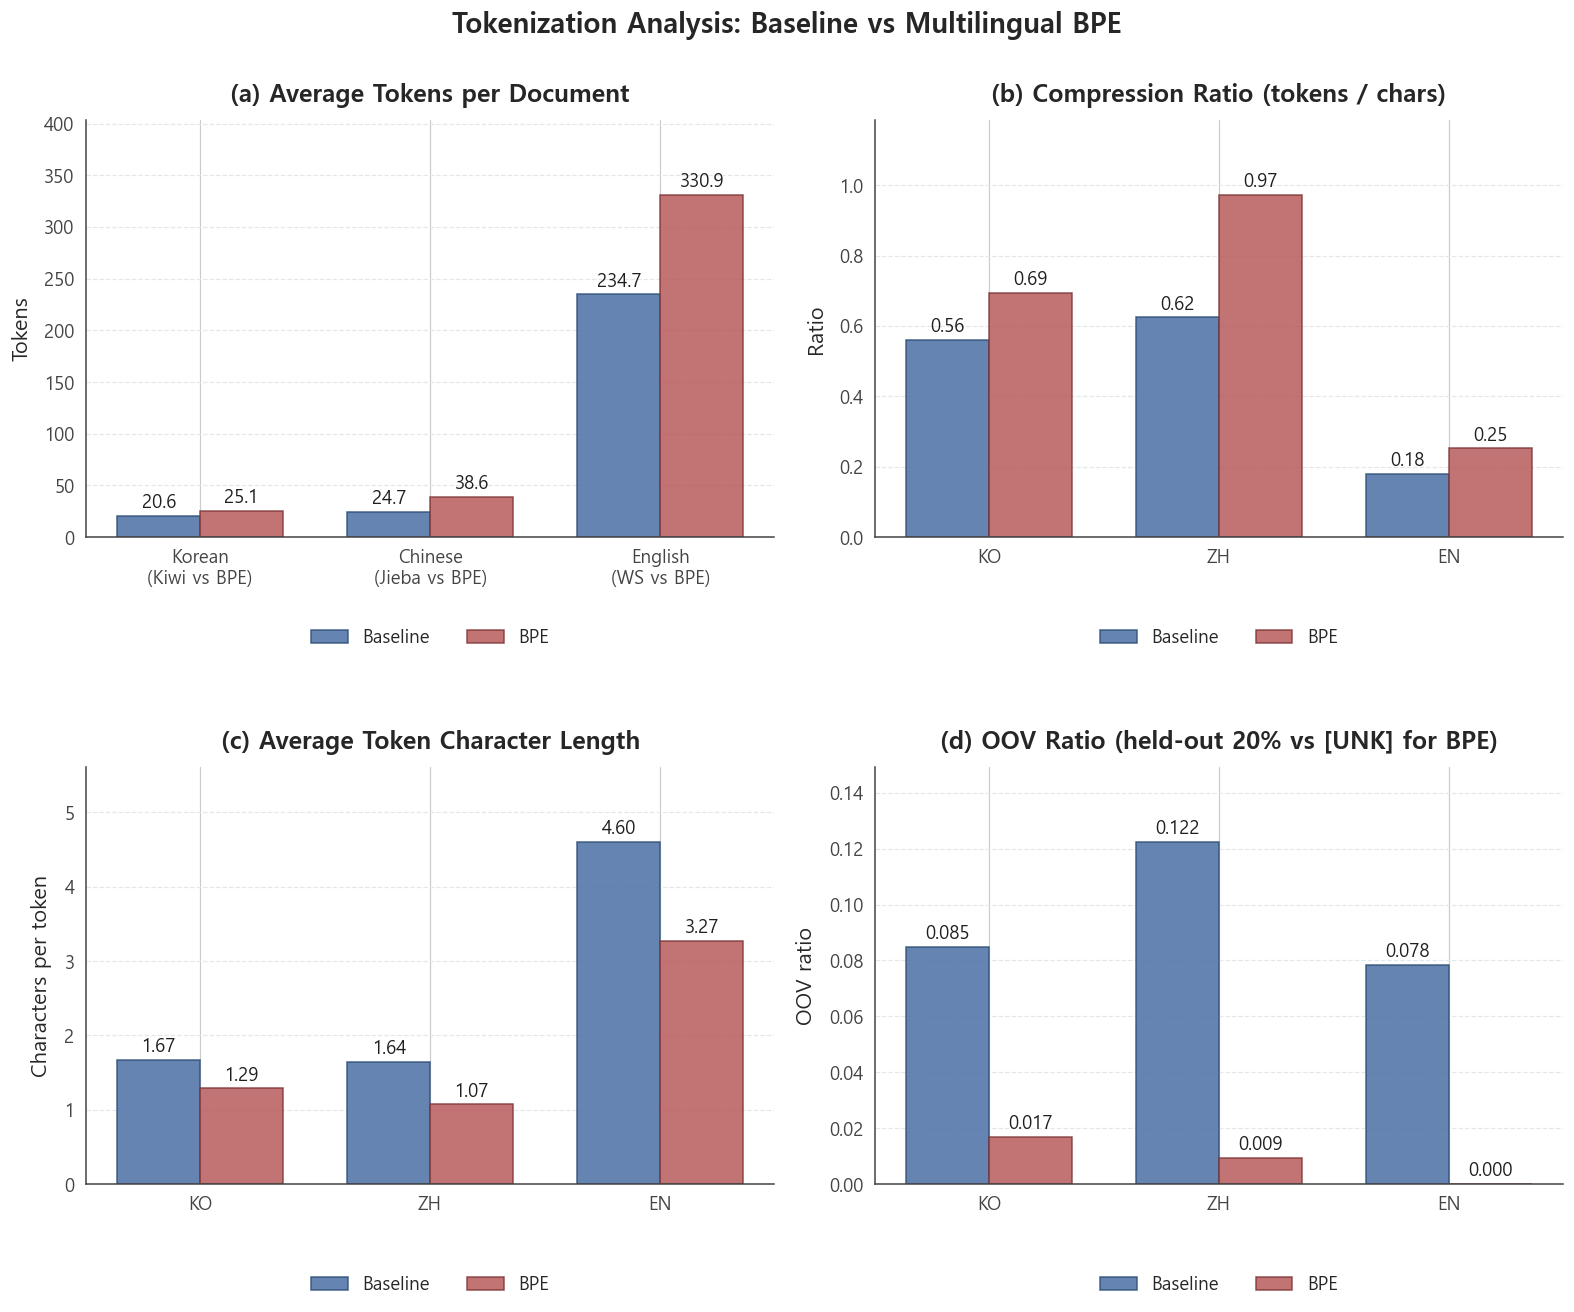


===== 3. STATIC EMBEDDING (WORD2VEC) =====
  [KO] vocab size: 2072
  [ZH] vocab size: 3286
  [EN] vocab size: 19115

Word2Vec nearest neighbors:

[KO]
  재미         -> 필요(0.99), 남(0.99), 잊(0.99)
  최고         -> 의(0.98), 과(0.98), 연기(0.98)
  실망         -> 이랑(1.00), 역시(1.00), 라서(1.00)
  별로         -> 참(1.00), 하나(1.00), 거의(1.00)
  사랑         -> 모습(1.00), 함께(1.00), 우리(1.00)

[ZH]
  好看         -> 好(0.98), 票(0.98), 哈哈哈(0.98)
  精彩         -> 厉害(1.00), 跟(1.00), 那个(1.00)
  失望         -> 有些(1.00), 风格(1.00), 实在(1.00)
  垃圾         -> 组合(1.00), 离场(0.99), 一次次(0.99)
  喜欢         -> 情节(0.99), 结尾(0.99), 韩国(0.99)

[EN]
  great      -> wonderful(0.79), nice(0.73), brilliant(0.73)
  amazing    -> predictable(0.80), excellent(0.79), fantastic(0.79)
  terrible   -> horrible(0.85), awful(0.84), weak(0.82)
  boring     -> disturbing(0.81), disappointing(0.80), unique,(0.80)
  love       -> love.(0.62), hate(0.59), understand.(0.58)

===== 4. CONTEXTUAL EMBEDDING (BERT) =====

[EN] target = 'love'
  S1 vs S2: c

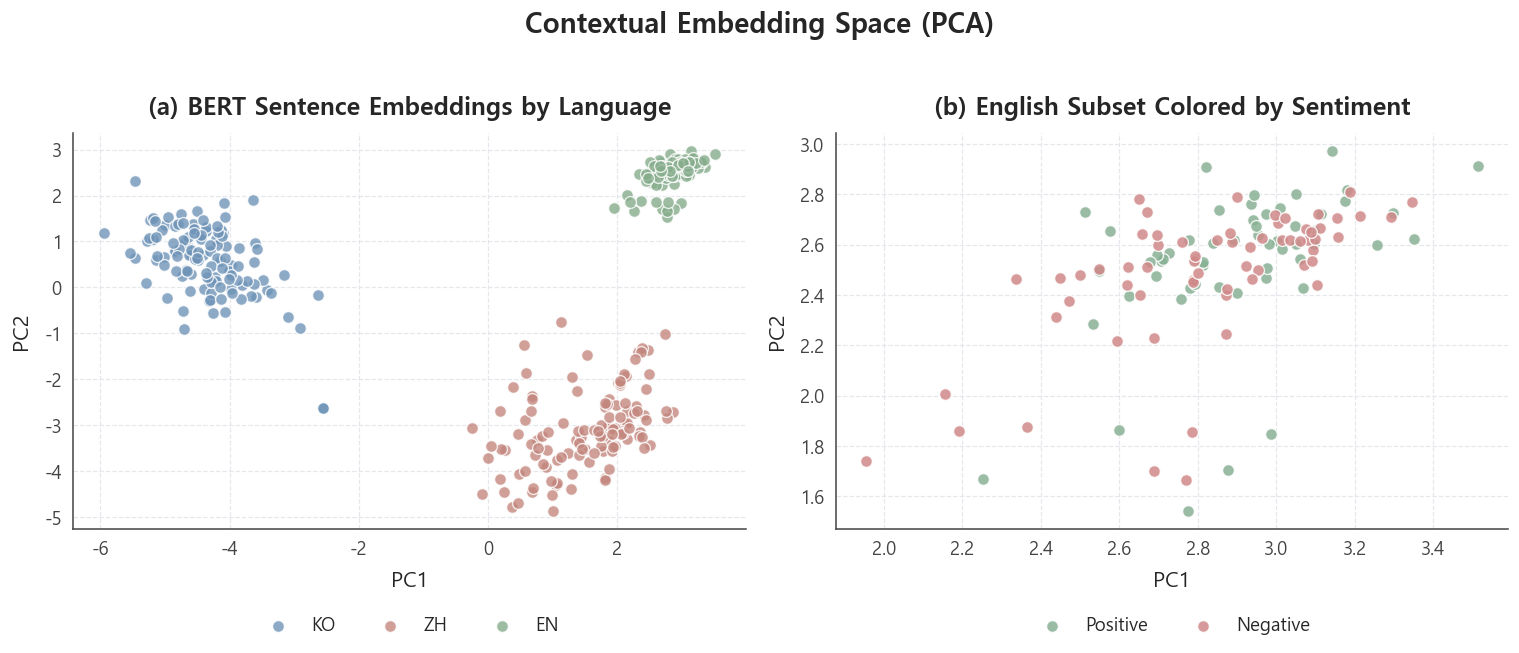

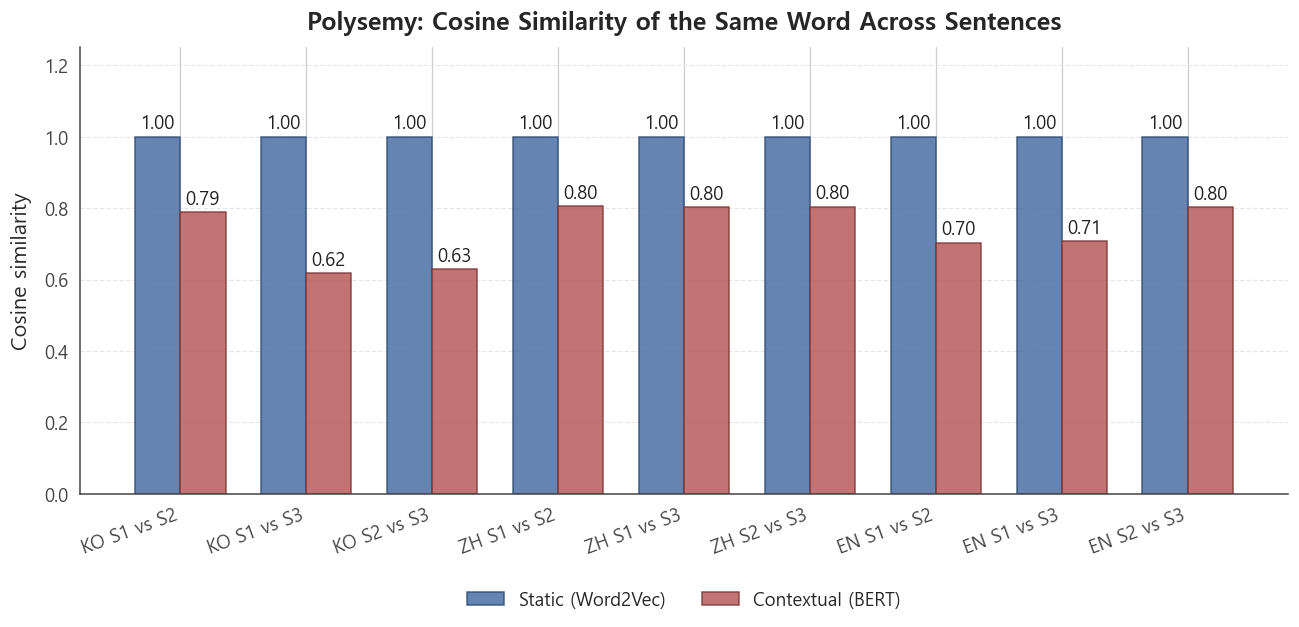


===== 5. ATTENTION =====

[EN | with_but] focus='but' | The acting was brilliant but the story was weak.
  Layer 0  focus_attn = 0.0534  span=['but']
  Layer 5  focus_attn = 0.0630  span=['but']

[EN | no_but] focus='enjoyed' | I really enjoyed this movie from start to finish.
  Layer 0  focus_attn = 0.0674  span=['enjoyed']
  Layer 5  focus_attn = 0.0950  span=['enjoyed']


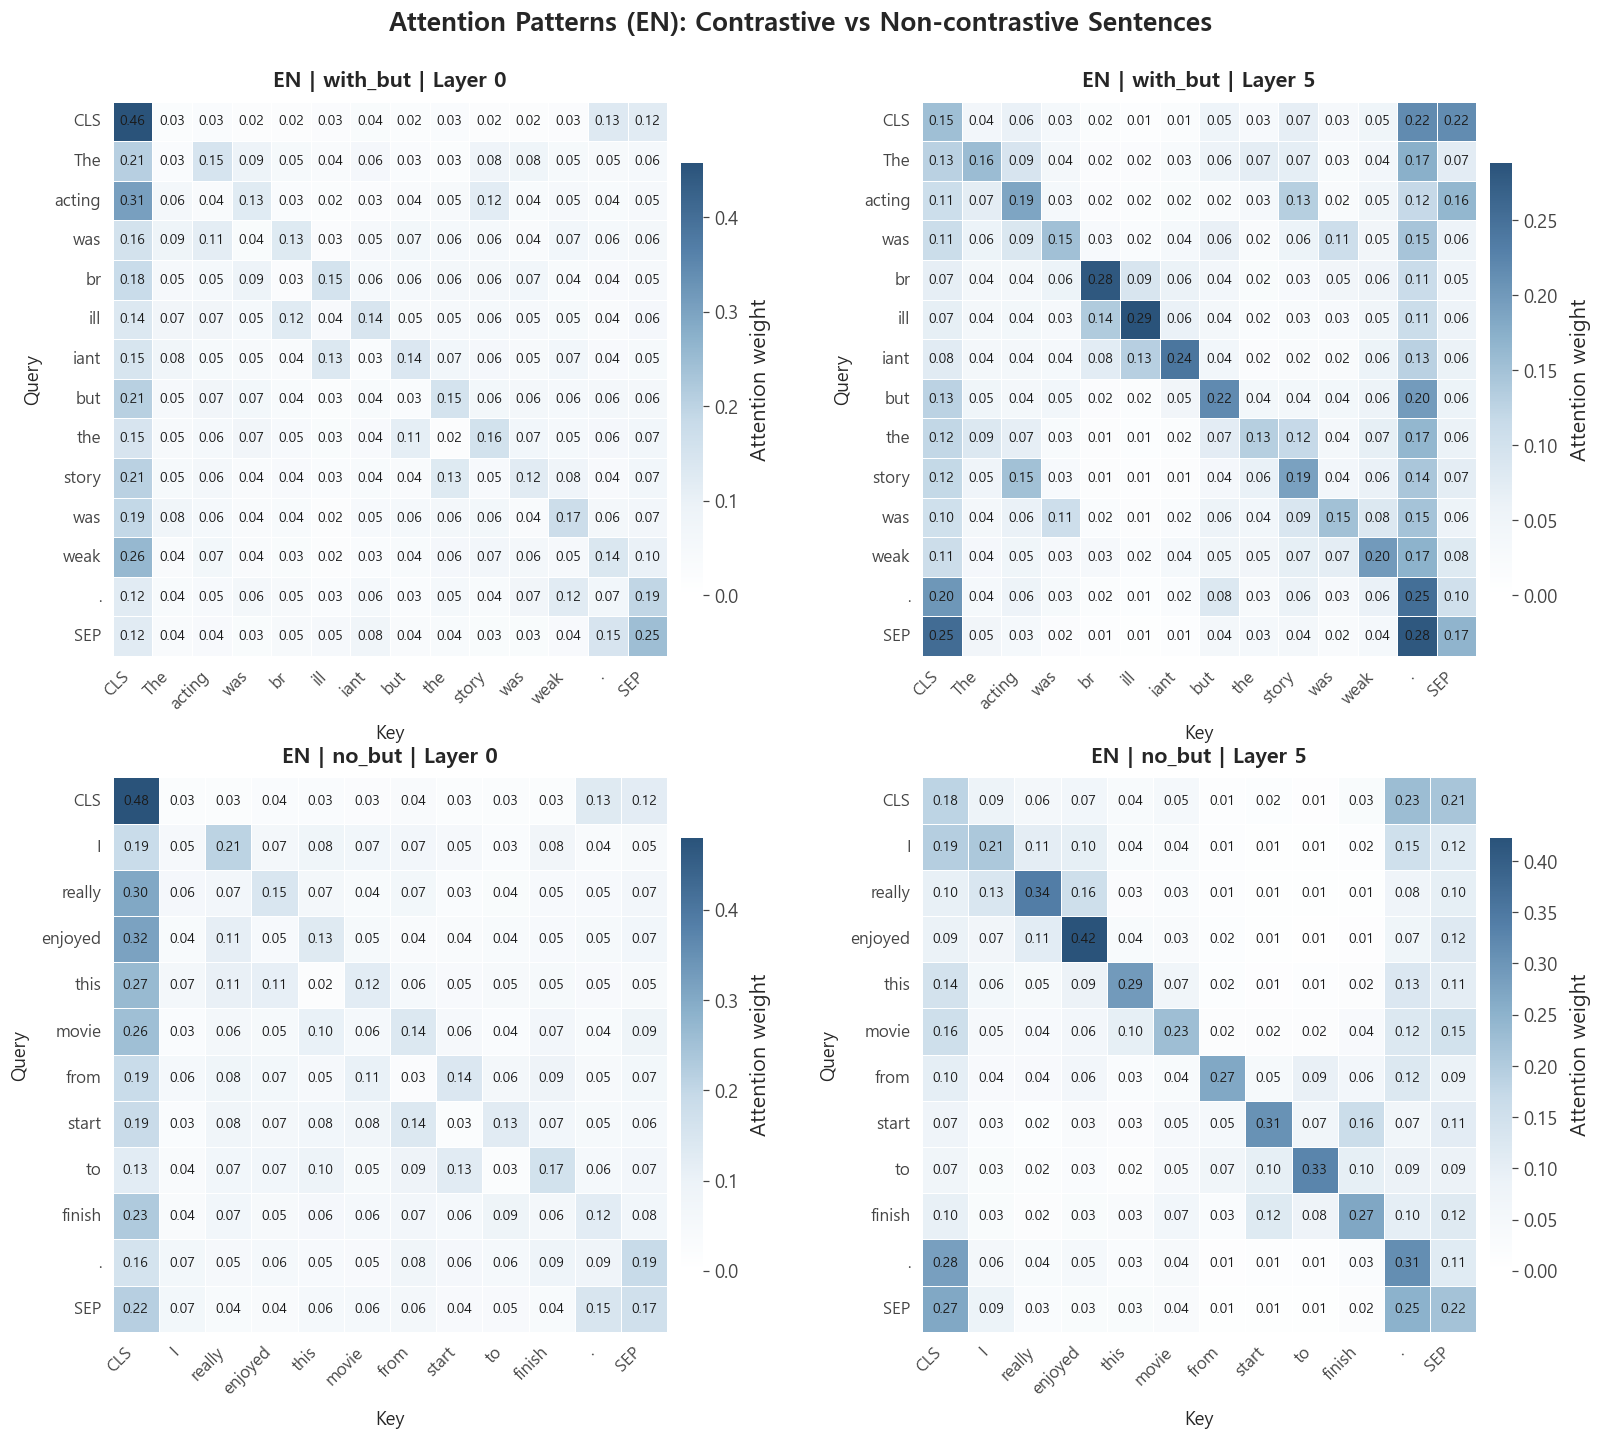


[ZH | with_but] focus='但是' | 剧情很好看但是节奏太慢了
  Layer 0  focus_attn = 0.0605  span=['但', '是']
  Layer 5  focus_attn = 0.0606  span=['但', '是']

[ZH | no_but] focus='精彩' | 这部电影非常精彩演员表演也很出色
  Layer 0  focus_attn = 0.0435  span=['精', '彩']
  Layer 5  focus_attn = 0.0476  span=['精', '彩']


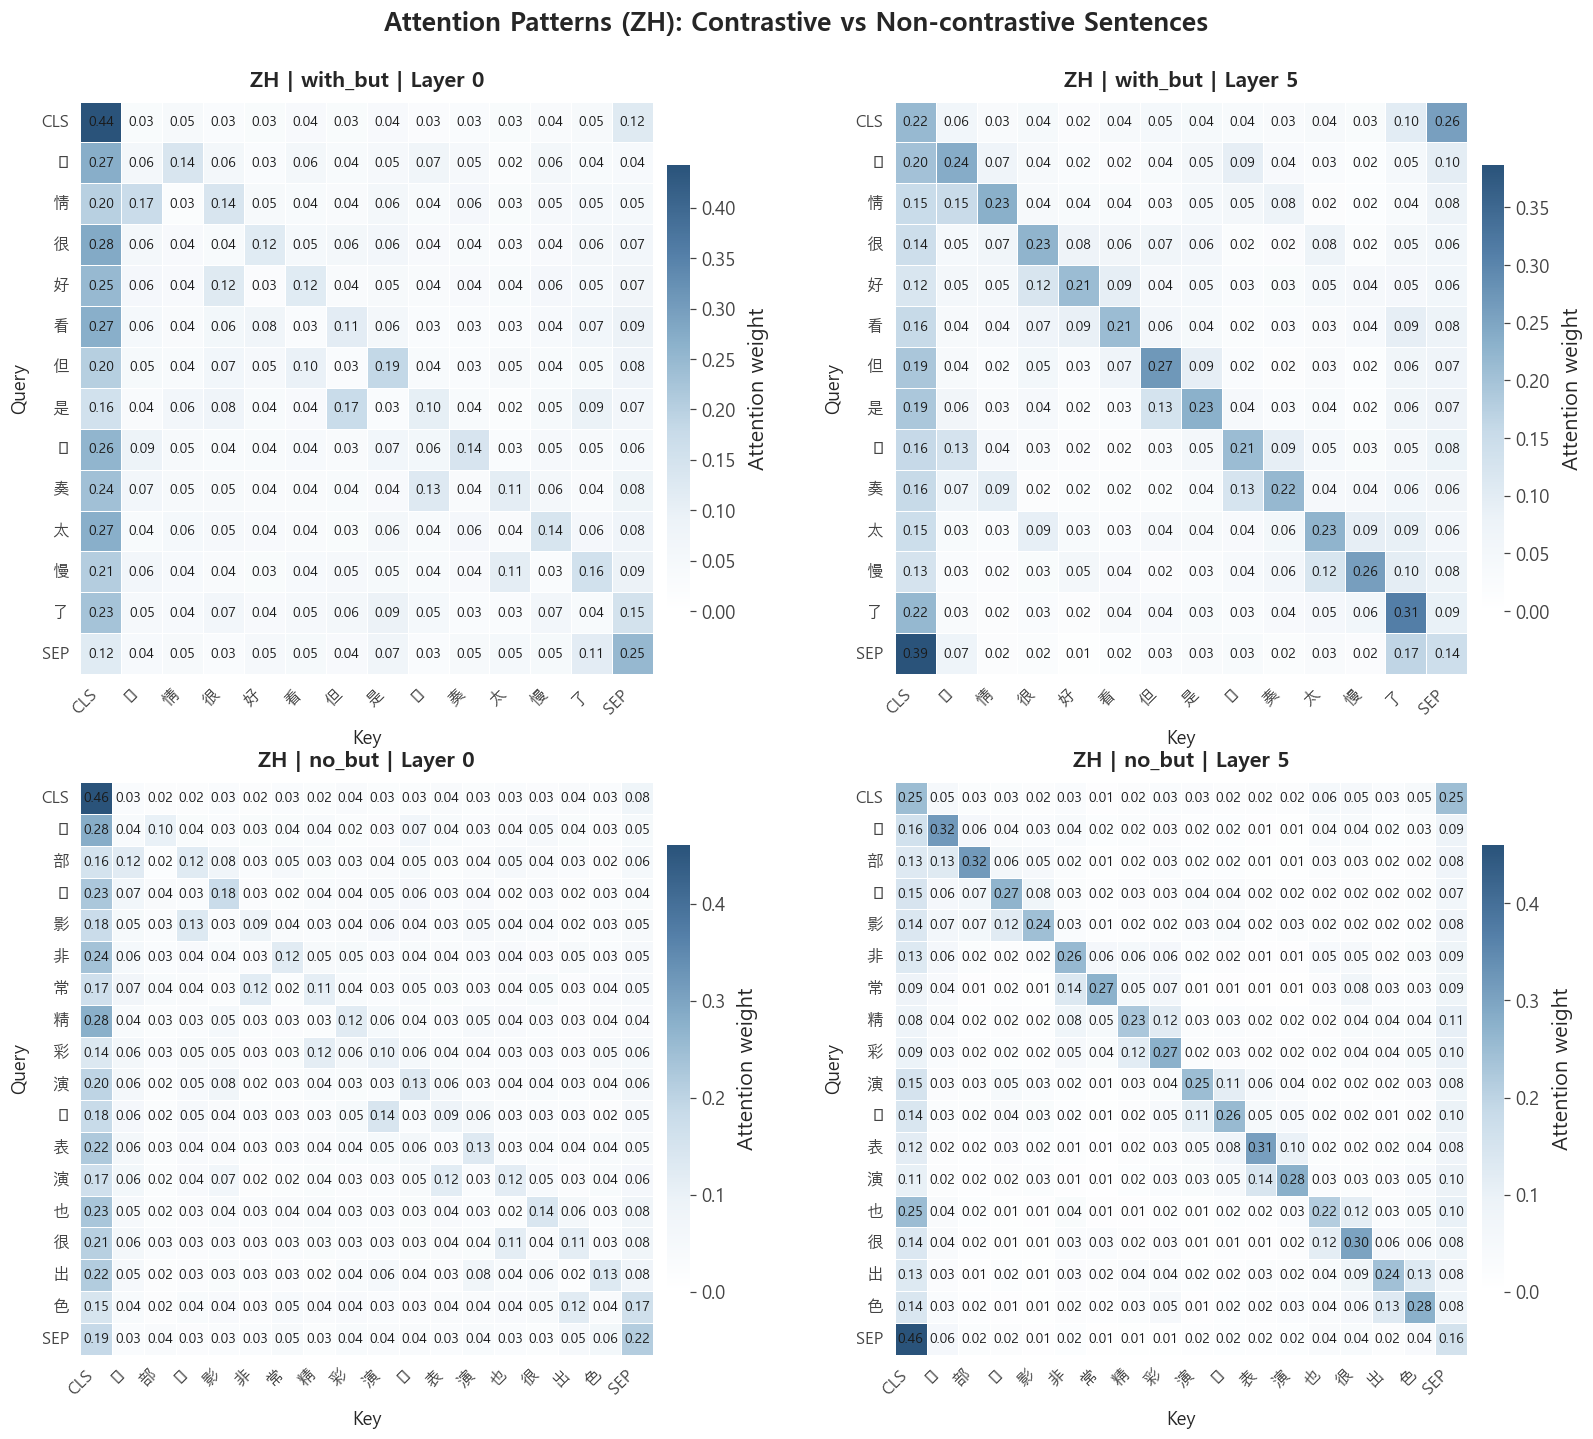


[KO | with_but] focus='지만' | 연기는 좋았지만 스토리는 실망스러웠다
  Layer 0  focus_attn = 0.0465  span=['지만']
  Layer 5  focus_attn = 0.0552  span=['지만']

[KO | no_but] focus='재미' | 이 영화는 정말 재미있고 감동적이었다
  Layer 0  focus_attn = 0.0509  span=['재', '미']
  Layer 5  focus_attn = 0.0528  span=['재', '미']


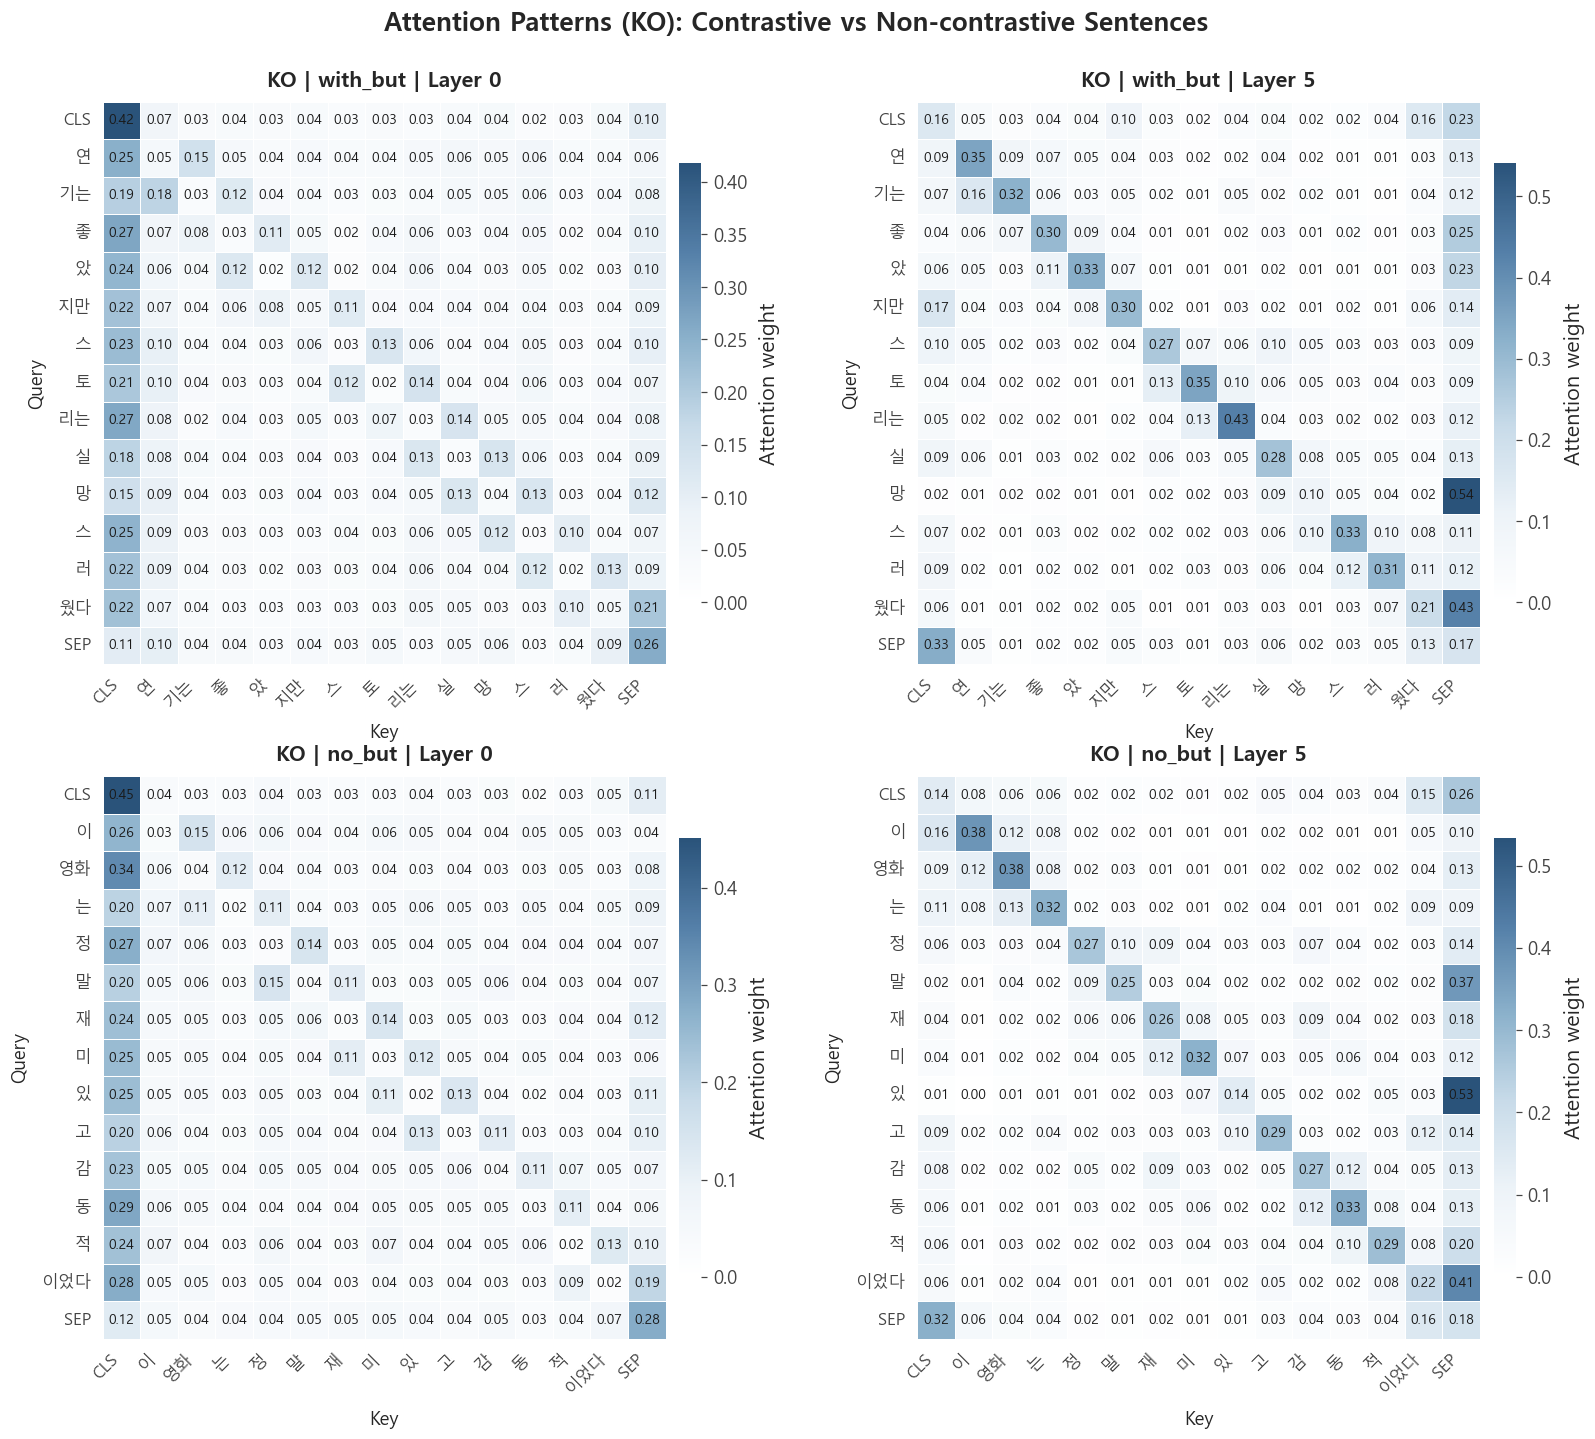


Focus attention summary:
lang     kind  layer   focus     attn
  ko with_but      0      지만 0.046547
  ko with_but      5      지만 0.055167
  ko   no_but      0      재미 0.050875
  ko   no_but      5      재미 0.052834
  zh with_but      0      但是 0.060469
  zh with_but      5      但是 0.060596
  zh   no_but      0      精彩 0.043530
  zh   no_but      5      精彩 0.047564
  en with_but      0     but 0.053407
  en with_but      5     but 0.063040
  en   no_but      0 enjoyed 0.067438
  en   no_but      5 enjoyed 0.094962


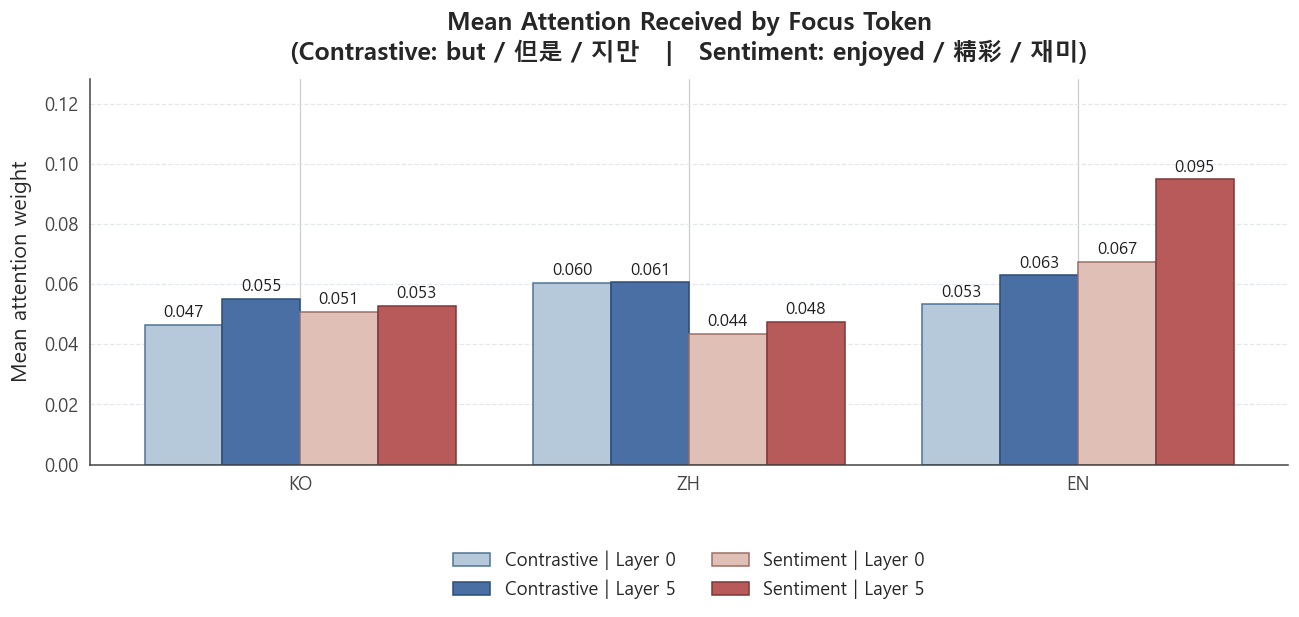


===== 6. MODEL COMPARISON =====
Train: 4800, Test: 1200

--- BASE (frozen backbone, classifier head only) ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable: 592,130 / 135,326,210 (0.44%)
[Base] epoch 1: loss=0.6859  test_acc=0.5625
[Base] epoch 2: loss=0.6621  test_acc=0.5625
[Base] epoch 3: loss=0.6514  test_acc=0.6633
[Base] epoch 4: loss=0.6452  test_acc=0.6692
[Base] epoch 5: loss=0.6379  test_acc=0.6500
[Base] epoch 6: loss=0.6337  test_acc=0.6467
BASE final: acc=0.6467  f1=0.6409
              precision    recall  f1-score   support

    negative       0.62      0.77      0.69       600
    positive       0.70      0.52      0.60       600

    accuracy                           0.65      1200
   macro avg       0.66      0.65      0.64      1200
weighted avg       0.66      0.65      0.64      1200


--- SFT (full fine-tune) ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable: 135,326,210 / 135,326,210 (100.00%)
[SFT] epoch 1: loss=0.6333  test_acc=0.7458
[SFT] epoch 2: loss=0.4496  test_acc=0.7475
[SFT] epoch 3: loss=0.2820  test_acc=0.7617
SFT final: acc=0.7617  f1=0.7614
              precision    recall  f1-score   support

    negative       0.78      0.73      0.75       600
    positive       0.75      0.79      0.77       600

    accuracy                           0.76      1200
   macro avg       0.76      0.76      0.76      1200
weighted avg       0.76      0.76      0.76      1200


--- LoRA ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 739,586 || all params: 136,065,796 || trainable%: 0.5436
[LoRA] epoch 1: loss=0.6476  test_acc=0.7017
[LoRA] epoch 2: loss=0.5590  test_acc=0.7392
[LoRA] epoch 3: loss=0.5027  test_acc=0.7300
[LoRA] epoch 4: loss=0.4523  test_acc=0.7383
[LoRA] epoch 5: loss=0.4014  test_acc=0.7525
LoRA final: acc=0.7525  f1=0.7524
              precision    recall  f1-score   support

    negative       0.74      0.77      0.76       600
    positive       0.76      0.74      0.75       600

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200


Per-language performance:
language  base_acc  base_f1  sft_acc   sft_f1  lora_acc  lora_f1
      ko    0.6275 0.618631   0.7350 0.734940    0.7050 0.704638
      zh    0.6125 0.607533   0.7525 0.752151    0.7450 0.744361
      en    0.7000 0.695979   0.7975 0.796430    0.8075 0.806745


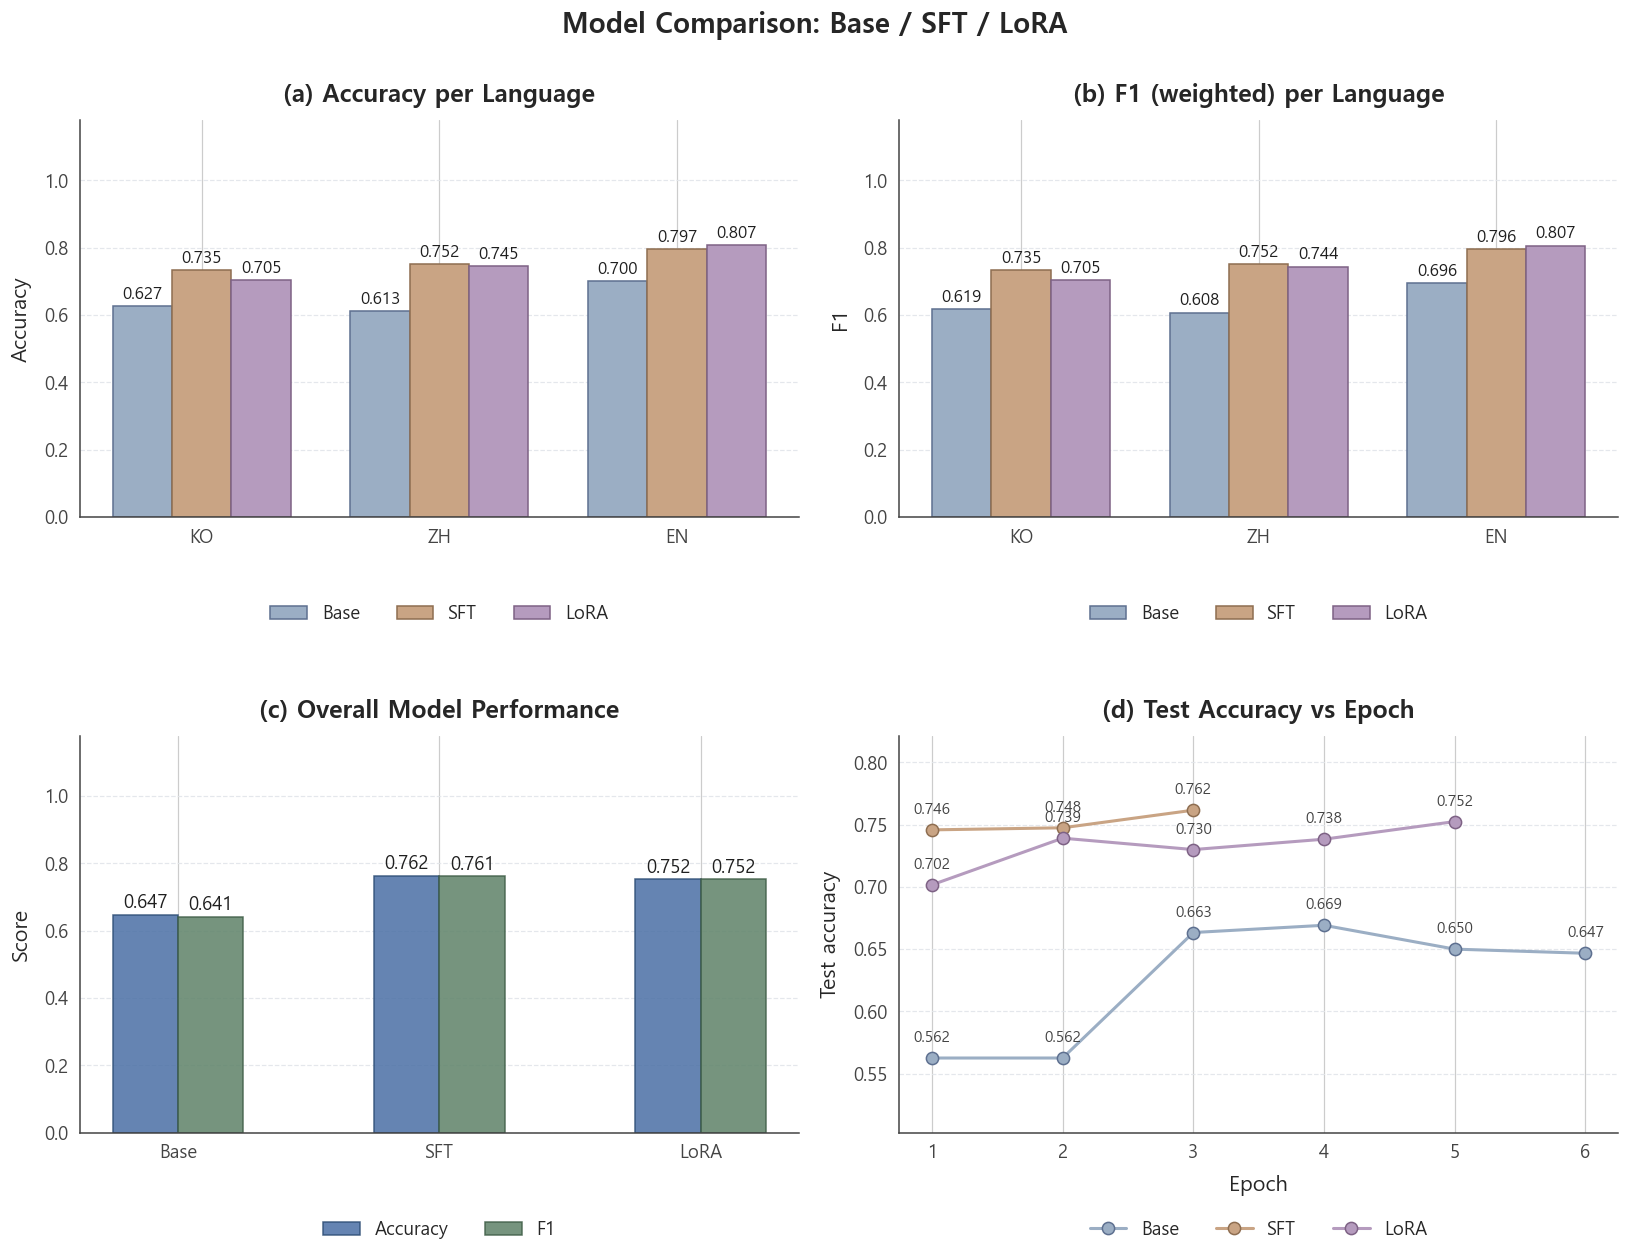


===== 7. ERROR ANALYSIS (LoRA) =====
Total errors: 297 / 1200

Error rate by language:
          errors  total    rate
language                       
ko           118    400  0.2950
zh           102    400  0.2550
en            77    400  0.1925


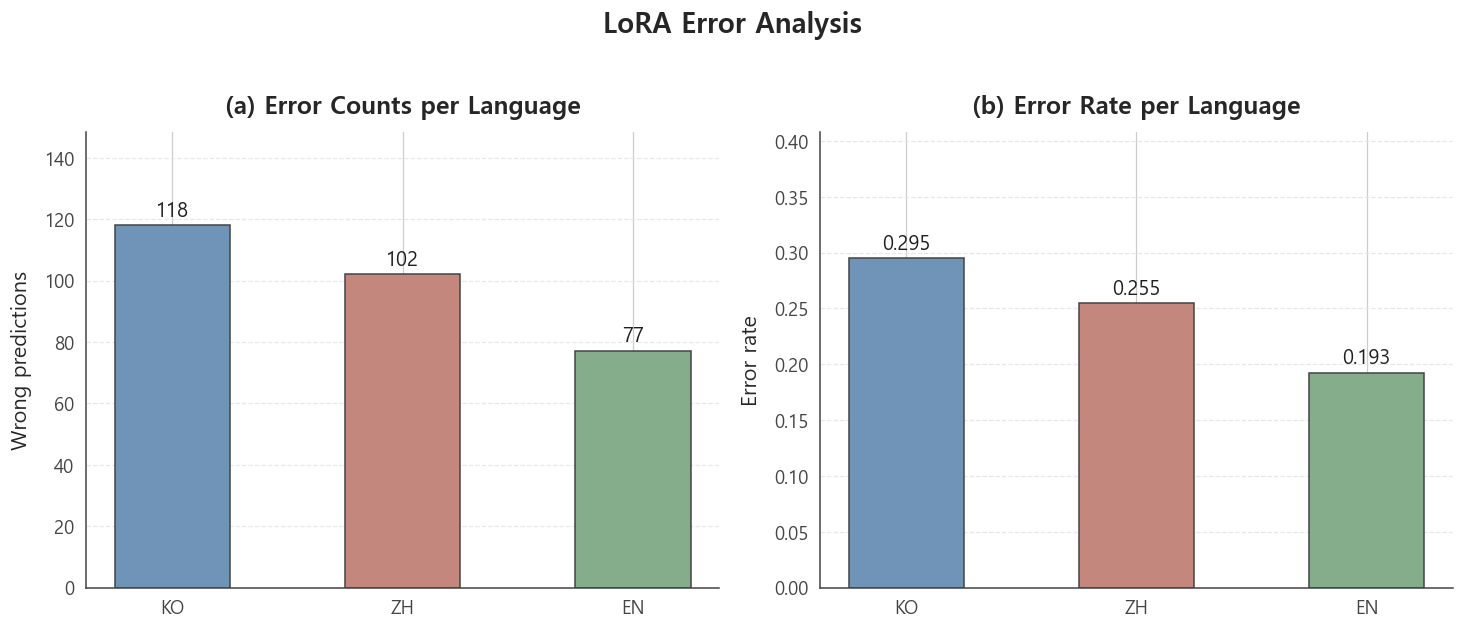


--- Representative error samples ---

[ko] true=positive  pred=negative
  text: 내용이 너무 가볍지도 않고 재밌는거같아요 보통이 마테오빠 다비드 잭히사장다맘에듬

[ko] true=positive  pred=negative
  text: 질질끄는것 없고 화끈하게 코믹, 복잡X, 배우들 다 매력적 이탈리아어배우고싶음 ㅋ

[zh] true=negative  pred=positive
  text: 看完书后看的电影 感觉没有书写的好 尤其是胡夏最不符合尤他的角色 尤他是属于睿智的清华生 眼色的睿智和举手投足的自信 胡夏表达的不够明显 而且张漾踢吧啦是为了踢掉孩子 而不是恨吧啦威胁他 苏有朋把小说的顺序打乱 看上去一点都不现实 小说里的残酷和现实在电影里表现的就没那么酣畅了

[zh] true=positive  pred=negative
  text: 冬兵离接任第二代美国对象不远了吧 对 队长！

[en] true=positive  pred=negative
  text: believe it or not, at 12 minutes, this film (for 1912) is a full-length film. very, very few films were longer than that back then, but that is definitely not what sets this odd little film apart from the rest! no, what's different is that 

[en] true=negative  pred=positive
  text: the premise of the movie has been explained and if you've gotten this far you don't me to pretend that i'm a movie critic. with that being said my own opinion of the movie is quite low. i'm a fan of takashi mi

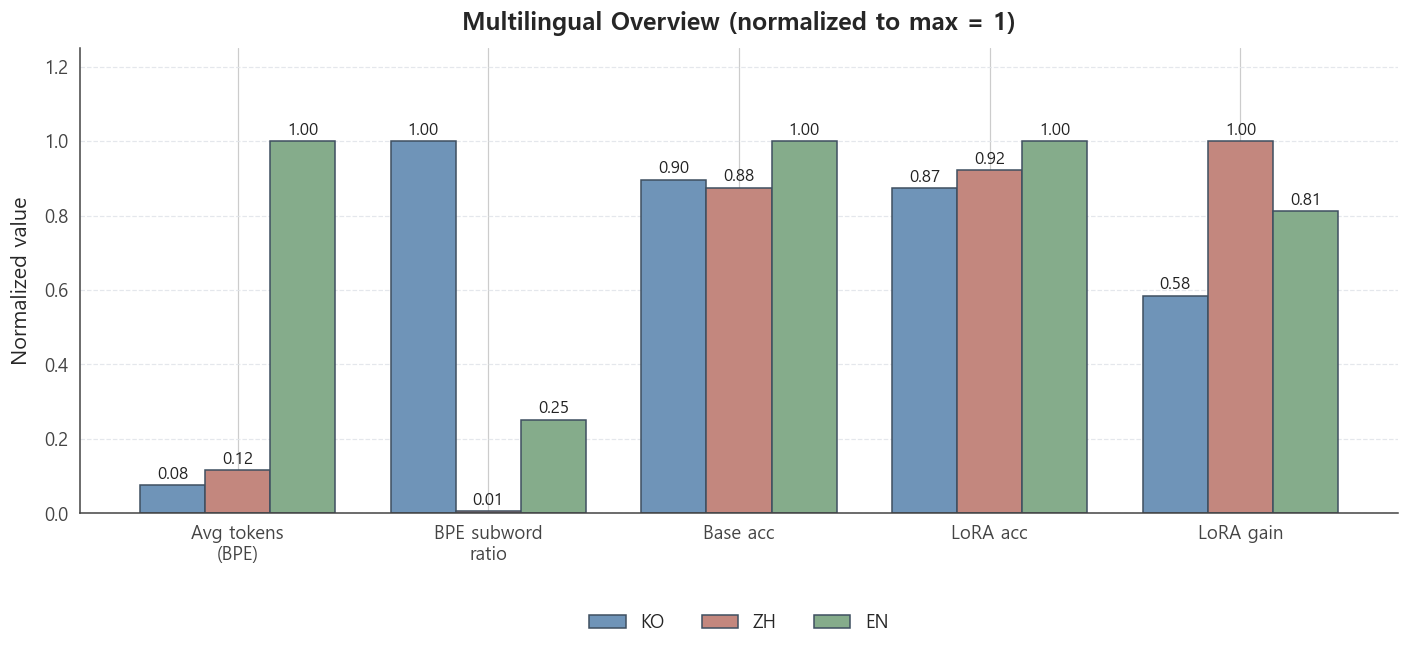


All figures saved to: D:\xianyu4\4.22\6\img
Done.


In [2]:


import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score, classification_report

from gensim.models import Word2Vec
import jieba
from kiwipiepy import Kiwi

from transformers import (AutoTokenizer, AutoModel,
                          AutoModelForSequenceClassification, set_seed)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings("ignore")

# ================================================================
# Reproducibility
# ================================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

IMG_DIR = Path("img")
IMG_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


def _pick_cjk_fonts():

    preferred = [
        # True cross-CJK fonts (if installed)
        "Noto Sans CJK KR", "Noto Sans CJK SC", "Noto Sans CJK JP",
        "Source Han Sans KR", "Source Han Sans SC",
        "Arial Unicode MS",
        # *** Malgun Gothic FIRST on Windows: Hangul + common Hanzi ***
        "Malgun Gothic",
        # Chinese-only fonts (no Hangul, used as fallback for rarer Hanzi)
        "Microsoft YaHei", "SimHei", "SimSun",
        # macOS
        "PingFang SC", "Hiragino Sans GB", "AppleGothic",
        # Latin fallback
        "DejaVu Sans",
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    ordered = [name for name in preferred if name in installed]
    if "DejaVu Sans" not in ordered:
        ordered.append("DejaVu Sans")
    return ordered
    installed = {f.name for f in fm.fontManager.ttflist}
    ordered = [name for name in preferred if name in installed]
    # Always end with DejaVu Sans as a safety net
    if "DejaVu Sans" not in ordered:
        ordered.append("DejaVu Sans")
    return ordered


CJK_FONTS = _pick_cjk_fonts()
print(f"Font stack: {CJK_FONTS[:4]} ...")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": CJK_FONTS,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "semibold",
    "axes.titlepad": 12,
    "axes.labelsize": 14,
    "axes.labelpad": 8,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 280,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 1.0,
    "axes.unicode_minus": False,
    "xtick.major.size": 4, "ytick.major.size": 4,
    "xtick.color": "#444444", "ytick.color": "#444444",
})
# Turn on font fallback (matplotlib 3.6+); ignored silently on older versions.
try:
    mpl.rcParams["font.fallback"] = True
except Exception:
    pass

# Soft, publication-friendly palette
PAL = {
    "ko":       "#6F94B8",  "zh":       "#C3877E",  "en":       "#85AC8B",
    "ko_light": "#B5C9DB",  "zh_light": "#E0BFB7",  "en_light": "#BFD5C3",
    "positive": "#88B194",  "negative": "#D08989",
    "base":     "#9BAEC4",  "sft":      "#C9A484",  "lora":     "#B59BBE",
    "a1":       "#4A6FA5",  "a2":       "#B85A5A",  "a3":       "#5E8268",
    "grid":     "#E2E5EA",
}

HEAT_CMAP = LinearSegmentedColormap.from_list(
    "AcademicHeat",
    ["#FFFFFF", "#EDF3F8", "#C8DBE9", "#8BB1CB", "#547FA8", "#2A537A"],
)

LABEL_FS = 12


def annotate_bars(ax, bars, fmt="{:.3f}", fontsize=LABEL_FS, color="#1F1F1F"):
    y_top = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 0.012 * y_top,
                fmt.format(h), ha="center", va="bottom",
                fontsize=fontsize, color=color)


def style_axis(ax, title=None, xlabel=None, ylabel=None, grid=True):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid:
        ax.grid(axis="y", linestyle="--", color=PAL["grid"],
                linewidth=0.8, alpha=0.9)
        ax.set_axisbelow(True)


def legend_below(ax, ncol=None):
    h, l = ax.get_legend_handles_labels()
    if not h:
        return
    if ncol is None:
        ncol = min(len(h), 4)
    ax.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=ncol, frameon=False, fontsize=12)


def clean_token(t):
    if t is None: return ""
    if t.startswith("##"): return t[2:]
    return {"[CLS]": "CLS", "[SEP]": "SEP",
            "[PAD]": "PAD", "[UNK]": "UNK"}.get(t, t)


# ================================================================
# 1. DATA LOADING & CLEANING
# ================================================================
print("\n===== 1. DATA LOADING =====")

SAMPLE_PER_LANG = 2000
N_PER_CLASS = SAMPLE_PER_LANG // 2


def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def stratified_sample_by_movie(df, n_per_class, label_col="label",
                               movie_col="movie", seed=SEED):
    out = []
    for lab in ["positive", "negative"]:
        sub = df[df[label_col] == lab]
        movies = sub[movie_col].unique()
        per_movie = max(2, n_per_class // max(len(movies), 1))
        sampled = (sub.groupby(movie_col, group_keys=False)
                      .apply(lambda g: g.sample(min(len(g), per_movie),
                                                random_state=seed)))
        if len(sampled) < n_per_class:
            extra = sub.drop(sampled.index, errors="ignore")
            need = n_per_class - len(sampled)
            if len(extra) >= need:
                sampled = pd.concat(
                    [sampled, extra.sample(n=need, random_state=seed)])
        sampled = sampled.sample(n=n_per_class, random_state=seed)
        out.append(sampled)
    return pd.concat(out).reset_index(drop=True)


# Korean - NSMC
print("Loading Korean NSMC ...")
nsmc = pd.read_csv("./nsmc/nsmc_train.csv")
nsmc["text"] = nsmc["document"].astype(str).apply(clean_text)
nsmc = nsmc[nsmc["text"].str.contains(r"[\uAC00-\uD7A3]", na=False)]
nsmc["label"] = nsmc["label"].map({0: "negative", 1: "positive"})
nsmc = nsmc.dropna(subset=["text", "label"])
nsmc = nsmc[nsmc["text"].str.len() >= 5].drop_duplicates(subset="text")
nsmc["movie"] = "unknown"
nsmc_pos = nsmc[nsmc["label"] == "positive"].sample(n=N_PER_CLASS, random_state=SEED)
nsmc_neg = nsmc[nsmc["label"] == "negative"].sample(n=N_PER_CLASS, random_state=SEED)
nsmc_sample = pd.concat([nsmc_pos, nsmc_neg])
nsmc_sample["source"] = "nsmc"
nsmc_sample["language"] = "ko"
nsmc_sample = nsmc_sample[["text", "label", "source", "language", "movie"]]

# Chinese - Douban
print("Loading Chinese Douban ...")
douban = pd.read_csv("./douban/DMSC.csv",
                     usecols=["Movie_Name_CN", "Star", "Comment"])
douban = douban[douban["Star"] != 3]
douban["label"] = douban["Star"].apply(lambda s: "positive" if s >= 4 else "negative")
douban["text"] = douban["Comment"].astype(str).apply(clean_text)
douban["movie"] = douban["Movie_Name_CN"].astype(str)
douban = douban.dropna(subset=["text", "label", "movie"])
douban = douban[douban["text"].str.len() >= 5].drop_duplicates(subset="text")
print(f"  Douban candidate pool: {len(douban)} rows across "
      f"{douban['movie'].nunique()} movies")
douban_sample = stratified_sample_by_movie(douban, N_PER_CLASS,
                                           "label", "movie", SEED)
print(f"  After multi-movie stratified sampling: {len(douban_sample)} rows "
      f"covering {douban_sample['movie'].nunique()} movies")
douban_sample["source"] = "douban"
douban_sample["language"] = "zh"
douban_sample = douban_sample[["text", "label", "source", "language", "movie"]]

# English - IMDB
print("Loading English IMDB ...")
imdb = pd.read_csv("./IMDB/IMDB Dataset.csv")
imdb["text"] = imdb["review"].astype(str).apply(clean_text).str.lower()
imdb["label"] = imdb["sentiment"].str.lower()
imdb = imdb.dropna(subset=["text", "label"])
imdb = imdb[imdb["text"].str.len() >= 5].drop_duplicates(subset="text")
imdb["movie"] = "unknown"
imdb_pos = imdb[imdb["label"] == "positive"].sample(n=N_PER_CLASS, random_state=SEED)
imdb_neg = imdb[imdb["label"] == "negative"].sample(n=N_PER_CLASS, random_state=SEED)
imdb_sample = pd.concat([imdb_pos, imdb_neg])
imdb_sample["source"] = "imdb"
imdb_sample["language"] = "en"
imdb_sample = imdb_sample[["text", "label", "source", "language", "movie"]]

data = pd.concat([nsmc_sample, douban_sample, imdb_sample], ignore_index=True)
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
data.to_csv("data.csv", index=False, encoding="utf-8-sig")

print(f"\nTotal samples: {len(data)}")
print("Distribution by language x label:")
print(data.groupby(["language", "label"]).size().unstack())

fig, ax = plt.subplots(figsize=(9, 5.6))
dist = data.groupby(["language", "label"]).size().unstack()
x = np.arange(len(dist.index)); width = 0.36
b1 = ax.bar(x - width / 2, dist["positive"], width, label="Positive",
            color=PAL["positive"], edgecolor="#5C826A", linewidth=1.0)
b2 = ax.bar(x + width / 2, dist["negative"], width, label="Negative",
            color=PAL["negative"], edgecolor="#9B5757", linewidth=1.0)
annotate_bars(ax, b1, fmt="{:.0f}", fontsize=13)
annotate_bars(ax, b2, fmt="{:.0f}", fontsize=13)
ax.set_xticks(x); ax.set_xticklabels([s.upper() for s in dist.index])
ax.set_ylim(0, dist.values.max() * 1.18)
style_axis(ax, title="Sample Counts per Language and Label",
           ylabel="Number of samples")
legend_below(ax, ncol=2)
plt.tight_layout()
plt.savefig(IMG_DIR / "00_data_distribution.png")
plt.show()


# ================================================================
# 2. TOKENIZATION ANALYSIS
# ================================================================
print("\n===== 2. TOKENIZATION =====")

BPE_MODEL = "distilbert-base-multilingual-cased"
bpe_tok = AutoTokenizer.from_pretrained(BPE_MODEL)

kiwi = Kiwi()
def tok_ko(text): return [t.form for t in kiwi.tokenize(text)]
def tok_zh(text): return [t for t in jieba.lcut(text) if t.strip()]
def tok_en(text): return text.split()

baseline_tok = {
    "ko": ("Kiwi",       tok_ko),
    "zh": ("Jieba",      tok_zh),
    "en": ("Whitespace", tok_en),
}


def baseline_stats(texts, tokenize_fn):
    n_train = int(len(texts) * 0.8)
    train_texts = texts[:n_train]
    test_texts  = texts[n_train:]

    vocab = set()
    for t in train_texts:
        vocab.update(tokenize_fn(t))

    oov = total = 0
    for t in test_texts:
        for x in tokenize_fn(t):
            total += 1
            if x not in vocab:
                oov += 1

    counts, char_lens, all_toks = [], [], []
    for t in texts:
        toks = tokenize_fn(t)
        counts.append(len(toks))
        if toks:
            char_lens.append(np.mean([len(x) for x in toks]))
        all_toks.extend(toks)

    return {
        "avg_tokens": float(np.mean(counts)),
        "avg_token_char_len": float(np.mean(char_lens)) if char_lens else 0.0,
        "compression_ratio": float(np.mean(
            [c / max(len(t), 1) for c, t in zip(counts, texts)])),
        "oov_ratio": oov / max(total, 1),
        "unique_types": len(set(all_toks)),
    }


def bpe_stats(texts):
    counts, char_lens = [], []
    sub_cnt = total = unk = 0
    all_toks = []
    for t in texts:
        toks = bpe_tok.tokenize(t)
        counts.append(len(toks))
        if toks:
            char_lens.append(np.mean([len(x.replace("##", "")) for x in toks]))
        for x in toks:
            total += 1
            if x.startswith("##"):
                sub_cnt += 1
            if x == "[UNK]":
                unk += 1
        all_toks.extend(toks)
    return {
        "avg_tokens": float(np.mean(counts)),
        "avg_token_char_len": float(np.mean(char_lens)) if char_lens else 0.0,
        "compression_ratio": float(np.mean(
            [c / max(len(t), 1) for c, t in zip(counts, texts)])),
        "subword_ratio": sub_cnt / max(total, 1),
        "oov_ratio": unk / max(total, 1),
        "unique_types": len(set(all_toks)),
    }


tok_rows = []
for lang in ["ko", "zh", "en"]:
    texts = data[data["language"] == lang]["text"].tolist()
    name, fn = baseline_tok[lang]
    bs = baseline_stats(texts, fn)
    bp = bpe_stats(texts)
    tok_rows.append({
        "language": lang, "baseline_name": name,
        "base_avg_tokens":      bs["avg_tokens"],
        "bpe_avg_tokens":       bp["avg_tokens"],
        "base_token_char_len":  bs["avg_token_char_len"],
        "bpe_token_char_len":   bp["avg_token_char_len"],
        "base_compression":     bs["compression_ratio"],
        "bpe_compression":      bp["compression_ratio"],
        "base_oov":             bs["oov_ratio"],
        "bpe_oov":              bp["oov_ratio"],
        "bpe_subword_ratio":    bp["subword_ratio"],
    })
tok_df = pd.DataFrame(tok_rows)
print("\nTokenization statistics:")
print(tok_df.to_string(index=False))


def _twin_bar(ax, base_v, bpe_v, fmt, title, ylab, xlabs):
    x = np.arange(len(base_v)); width = 0.36
    b1 = ax.bar(x - width / 2, base_v, width, label="Baseline",
                color=PAL["a1"], alpha=0.85,
                edgecolor="#2D4D75", linewidth=1.0)
    b2 = ax.bar(x + width / 2, bpe_v, width, label="BPE",
                color=PAL["a2"], alpha=0.85,
                edgecolor="#7E3737", linewidth=1.0)
    annotate_bars(ax, b1, fmt=fmt, fontsize=12)
    annotate_bars(ax, b2, fmt=fmt, fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(xlabs)
    ax.set_ylim(0, max(max(base_v), max(bpe_v)) * 1.22 + 1e-6)
    style_axis(ax, title=title, ylabel=ylab)
    legend_below(ax, ncol=2)


fig, axes = plt.subplots(2, 2, figsize=(14.5, 12))
langs = ["ko", "zh", "en"]
xlabs_a = ["Korean\n(Kiwi vs BPE)",
           "Chinese\n(Jieba vs BPE)",
           "English\n(WS vs BPE)"]
xlabs_b = [l.upper() for l in langs]

bv = [tok_df[tok_df["language"] == l]["base_avg_tokens"].iloc[0]   for l in langs]
pv = [tok_df[tok_df["language"] == l]["bpe_avg_tokens"].iloc[0]    for l in langs]
_twin_bar(axes[0, 0], bv, pv, "{:.1f}",
          "(a) Average Tokens per Document", "Tokens", xlabs_a)

bv = [tok_df[tok_df["language"] == l]["base_compression"].iloc[0]  for l in langs]
pv = [tok_df[tok_df["language"] == l]["bpe_compression"].iloc[0]   for l in langs]
_twin_bar(axes[0, 1], bv, pv, "{:.2f}",
          "(b) Compression Ratio (tokens / chars)", "Ratio", xlabs_b)

bv = [tok_df[tok_df["language"] == l]["base_token_char_len"].iloc[0] for l in langs]
pv = [tok_df[tok_df["language"] == l]["bpe_token_char_len"].iloc[0]  for l in langs]
_twin_bar(axes[1, 0], bv, pv, "{:.2f}",
          "(c) Average Token Character Length", "Characters per token", xlabs_b)

bv = [tok_df[tok_df["language"] == l]["base_oov"].iloc[0]          for l in langs]
pv = [tok_df[tok_df["language"] == l]["bpe_oov"].iloc[0]           for l in langs]
_twin_bar(axes[1, 1], bv, pv, "{:.3f}",
          "(d) OOV Ratio (held-out 20% vs [UNK] for BPE)", "OOV ratio", xlabs_b)

plt.suptitle("Tokenization Analysis: Baseline vs Multilingual BPE",
             fontsize=18, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.subplots_adjust(hspace=0.55)
plt.savefig(IMG_DIR / "01_tokenization_overview.png")
plt.show()


# ================================================================
# 3. STATIC EMBEDDING (WORD2VEC)
# ================================================================
print("\n===== 3. STATIC EMBEDDING (WORD2VEC) =====")

w2v_models = {}
for lang in ["ko", "zh", "en"]:
    texts = data[data["language"] == lang]["text"].tolist()
    if lang == "ko":
        sents = [tok_ko(t) for t in texts]
    elif lang == "zh":
        sents = [tok_zh(t) for t in texts]
    else:
        sents = [tok_en(t.lower()) for t in texts]
    m = Word2Vec(sentences=sents, vector_size=100, window=5,
                 min_count=2, workers=1, seed=SEED, epochs=15)
    w2v_models[lang] = m
    print(f"  [{lang.upper()}] vocab size: {len(m.wv)}")

test_words = {
    "ko": ["재미", "최고", "실망", "별로", "사랑"],
    "zh": ["好看", "精彩", "失望", "垃圾", "喜欢"],
    "en": ["great", "amazing", "terrible", "boring", "love"],
}
print("\nWord2Vec nearest neighbors:")
for lang, words in test_words.items():
    print(f"\n[{lang.upper()}]")
    for w in words:
        if w in w2v_models[lang].wv:
            sims = w2v_models[lang].wv.most_similar(w, topn=3)
            print(f"  {w:10s} -> "
                  + ", ".join([f"{s[0]}({s[1]:.2f})" for s in sims]))
        else:
            print(f"  {w:10s} (out of vocab)")


# ================================================================
# 4. CONTEXTUAL EMBEDDING (BERT) + PCA
# ================================================================
print("\n===== 4. CONTEXTUAL EMBEDDING (BERT) =====")

MODEL_NAME = "distilbert-base-multilingual-cased"
bert_tok = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_emb = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
bert_emb.eval()


def bert_encode(text, return_all=False):
    with torch.no_grad():
        enc = bert_tok(text, return_tensors="pt",
                       truncation=True, max_length=128).to(DEVICE)
        out = bert_emb(**enc)
    if return_all:
        return (out.last_hidden_state.squeeze(0).cpu().numpy(),
                enc["input_ids"].squeeze(0).cpu().numpy())
    return out.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()


POLYSEMY = {
    "en": ("love", [
        "I love this movie so much.",
        "The love story is boring and cliche.",
        "It is a movie about love and loss.",
    ]),
    "zh": ("好", [
        "这部电影真的非常好看。",
        "演员演得好但剧情很差。",
        "好的电影需要好的故事。",
    ]),
    "ko": ("좋", [
        "이 영화 정말 좋아요.",
        "연기는 좋지만 스토리가 별로예요.",
        "좋은 영화를 만나는 건 어렵다.",
    ]),
}

polysemy_results = {}
for lang, (target, sents) in POLYSEMY.items():
    print(f"\n[{lang.upper()}] target = '{target}'")
    embs = []
    for s in sents:
        full, ids = bert_encode(s, return_all=True)
        toks = bert_tok.convert_ids_to_tokens(ids)
        idx = [i for i, t in enumerate(toks)
               if target in t.replace("##", "") and t not in ("[CLS]", "[SEP]")]
        if idx:
            embs.append((s, full[idx[0]]))
    pairs = []
    for i in range(len(embs)):
        for j in range(i + 1, len(embs)):
            cs = float(cosine_similarity([embs[i][1]], [embs[j][1]])[0, 0])
            pairs.append((f"S{i+1} vs S{j+1}", cs))
            print(f"  S{i+1} vs S{j+1}: cos = {cs:.4f}")
    polysemy_results[lang] = pairs


print("\nComputing sentence embeddings for PCA ...")
pca_sample = (data.groupby("language", group_keys=False)
                  .apply(lambda g: g.sample(n=120, random_state=SEED))
                  .reset_index(drop=True))
emb_mat = np.vstack([bert_encode(t) for t in pca_sample["text"]])
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(emb_mat)
pca_sample["pc1"], pca_sample["pc2"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
for lang in ["ko", "zh", "en"]:
    m = pca_sample["language"] == lang
    ax.scatter(pca_sample.loc[m, "pc1"], pca_sample.loc[m, "pc2"],
               color=PAL[lang], label=lang.upper(),
               alpha=0.80, s=60, edgecolor="white", linewidth=0.9)
style_axis(ax, title="(a) BERT Sentence Embeddings by Language",
           xlabel="PC1", ylabel="PC2", grid=False)
ax.grid(linestyle="--", color=PAL["grid"], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
legend_below(ax, ncol=3)

ax = axes[1]
m_en = pca_sample["language"] == "en"
for lab in ["positive", "negative"]:
    m = m_en & (pca_sample["label"] == lab)
    ax.scatter(pca_sample.loc[m, "pc1"], pca_sample.loc[m, "pc2"],
               color=PAL[lab], label=lab.capitalize(),
               alpha=0.85, s=60, edgecolor="white", linewidth=0.9)
style_axis(ax, title="(b) English Subset Colored by Sentiment",
           xlabel="PC1", ylabel="PC2", grid=False)
ax.grid(linestyle="--", color=PAL["grid"], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
legend_below(ax, ncol=2)

plt.suptitle("Contextual Embedding Space (PCA)",
             fontsize=18, fontweight="semibold", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "02_embedding_pca.png")
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
all_pairs = []
for lang in ["ko", "zh", "en"]:
    for tag, cs in polysemy_results[lang]:
        all_pairs.append((f"{lang.upper()} {tag}", cs))
xs = np.arange(len(all_pairs)); width = 0.36
static_v = [1.0] * len(all_pairs)
ctx_v    = [p[1] for p in all_pairs]
b1 = ax.bar(xs - width / 2, static_v, width, label="Static (Word2Vec)",
            color=PAL["a1"], alpha=0.85, edgecolor="#2D4D75", linewidth=1.0)
b2 = ax.bar(xs + width / 2, ctx_v, width, label="Contextual (BERT)",
            color=PAL["a2"], alpha=0.85, edgecolor="#7E3737", linewidth=1.0)
annotate_bars(ax, b1, fmt="{:.2f}", fontsize=12)
annotate_bars(ax, b2, fmt="{:.2f}", fontsize=12)
ax.set_xticks(xs)
ax.set_xticklabels([p[0] for p in all_pairs], rotation=20, ha="right")
ax.set_ylim(0, 1.25)
style_axis(ax, title="Polysemy: Cosine Similarity of the Same Word Across Sentences",
           ylabel="Cosine similarity")
legend_below(ax, ncol=2)
plt.tight_layout()
plt.savefig(IMG_DIR / "02_embedding_similarity.png")
plt.show()


# ================================================================
# 5. ATTENTION VISUALIZATION  (FIX A)
# ================================================================
print("\n===== 5. ATTENTION =====")

att_model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True).to(DEVICE)
att_model.eval()
N_LAYERS = att_model.config.num_hidden_layers   # DistilBERT has 6 layers

ATT_FOCUS = {
    "en": {
        "with_but": ("but",     "The acting was brilliant but the story was weak."),
        "no_but":   ("enjoyed", "I really enjoyed this movie from start to finish."),
    },
    "zh": {
        "with_but": ("但是", "剧情很好看但是节奏太慢了"),
        "no_but":   ("精彩", "这部电影非常精彩演员表演也很出色"),
    },
    "ko": {
        "with_but": ("지만", "연기는 좋았지만 스토리는 실망스러웠다"),
        "no_but":   ("재미", "이 영화는 정말 재미있고 감동적이었다"),
    },
}


def get_attention(sent, layer):
    with torch.no_grad():
        enc = bert_tok(sent, return_tensors="pt", truncation=True).to(DEVICE)
        out = att_model(**enc)
    att = out.attentions[layer][0].mean(dim=0).cpu().numpy()  # mean over heads
    ids = enc["input_ids"].squeeze(0).cpu().numpy()
    raw = bert_tok.convert_ids_to_tokens(ids)
    disp = [clean_token(t) for t in raw]
    return raw, disp, att


# ----------------------------------------------------------------
# FIX A: span-aware focus attention.
# Multilingual BPE often splits CJK focus words into 2+ subword
# tokens (e.g. '但是' -> ['但','是']; '재미' -> ['재','##미']).
# The previous implementation required the whole focus string to
# appear inside one token, so it returned 0 for those languages.
# We now (1) try single-token containment first, then (2) scan for
# the shortest contiguous span whose concatenation contains the
# focus, and average attention received by that span.
# ----------------------------------------------------------------
def focus_received_attention(raw_tokens, att, focus):
    SPECIAL = {"[CLS]", "[SEP]", "[PAD]", "[UNK]"}
    cleaned = [t.replace("##", "") for t in raw_tokens]
    cleaned_lower = [c.lower() for c in cleaned]
    f = focus.lower()

    col_mean = att.mean(axis=0)  # attention received by each position

    # (1) Single-token substring match
    hits = [i for i, t in enumerate(cleaned_lower)
            if f in t and raw_tokens[i] not in SPECIAL]
    if hits:
        return float(np.mean([col_mean[i] for i in hits])), hits

    # (2) Span match: smallest contiguous window whose concat contains `f`
    n = len(cleaned_lower)
    best = None
    for start in range(n):
        if raw_tokens[start] in SPECIAL:
            continue
        concat = ""
        for end in range(start, min(start + 8, n)):
            if raw_tokens[end] in SPECIAL:
                break
            concat += cleaned_lower[end]
            if f in concat:
                span = list(range(start, end + 1))
                if best is None or len(span) < len(best):
                    best = span
                break
    if best:
        return float(np.mean([col_mean[i] for i in best])), best
    return 0.0, []


def draw_heatmap(ax, att, labels, title):
    n = len(labels)
    if n <= 22:
        ann = np.round(att, 2)
        sns.heatmap(att, ax=ax, cmap=HEAT_CMAP, vmin=0, vmax=att.max(),
                    xticklabels=labels, yticklabels=labels,
                    square=True, linewidths=0.4, linecolor="white",
                    cbar=True,
                    cbar_kws={"shrink": 0.78, "pad": 0.02,
                              "label": "Attention weight"},
                    annot=ann, fmt=".2f",
                    annot_kws={"size": 9, "color": "#1A1A1A"})
    else:
        sns.heatmap(att, ax=ax, cmap=HEAT_CMAP, vmin=0, vmax=att.max(),
                    xticklabels=labels, yticklabels=labels,
                    square=True, linewidths=0.4, linecolor="white",
                    cbar=True,
                    cbar_kws={"shrink": 0.78, "pad": 0.02,
                              "label": "Attention weight"})
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("Key", fontsize=12); ax.set_ylabel("Query", fontsize=12)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(labels, rotation=0, fontsize=11)


for lang, sents in ATT_FOCUS.items():
    fig, axes = plt.subplots(2, 2, figsize=(15, 13))
    for r, (kind, (focus, sent)) in enumerate(sents.items()):
        print(f"\n[{lang.upper()} | {kind}] focus='{focus}' | {sent}")
        for c, layer in enumerate([0, N_LAYERS - 1]):
            raw, disp, att = get_attention(sent, layer)
            recv, span = focus_received_attention(raw, att, focus)
            span_str = [disp[i] for i in span] if span else []
            print(f"  Layer {layer}  focus_attn = {recv:.4f}  "
                  f"span={span_str}")
            draw_heatmap(axes[r, c], att, disp,
                         f"{lang.upper()} | {kind} | Layer {layer}")
    plt.suptitle(f"Attention Patterns ({lang.upper()}): "
                 f"Contrastive vs Non-contrastive Sentences",
                 fontsize=17, fontweight="semibold", y=1.0)
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"03_attention_{lang}.png")
    plt.show()


print("\nFocus attention summary:")
focus_rows = []
for lang in ["ko", "zh", "en"]:
    for kind, (focus, sent) in ATT_FOCUS[lang].items():
        for layer in [0, N_LAYERS - 1]:
            raw, disp, att = get_attention(sent, layer)
            v, _ = focus_received_attention(raw, att, focus)
            focus_rows.append({"lang": lang, "kind": kind, "layer": layer,
                               "focus": focus, "attn": v})
focus_df = pd.DataFrame(focus_rows)
print(focus_df.to_string(index=False))


def get_v(kind, layer):
    return [focus_df[(focus_df["lang"] == l) &
                     (focus_df["kind"] == kind) &
                     (focus_df["layer"] == layer)]["attn"].iloc[0]
            for l in ["ko", "zh", "en"]]


fig, ax = plt.subplots(figsize=(12, 6))
groups = ["ko", "zh", "en"]
x = np.arange(len(groups)); width = 0.20

wb_l0 = get_v("with_but", 0)
wb_lf = get_v("with_but", N_LAYERS - 1)
nb_l0 = get_v("no_but",   0)
nb_lf = get_v("no_but",   N_LAYERS - 1)

b1 = ax.bar(x - 1.5 * width, wb_l0, width, label="Contrastive | Layer 0",
            color=PAL["ko_light"], edgecolor="#4F7497", linewidth=1.0)
b2 = ax.bar(x - 0.5 * width, wb_lf, width,
            label=f"Contrastive | Layer {N_LAYERS - 1}",
            color=PAL["a1"], edgecolor="#2D4D75", linewidth=1.0)
b3 = ax.bar(x + 0.5 * width, nb_l0, width, label="Sentiment | Layer 0",
            color=PAL["zh_light"], edgecolor="#9C6F66", linewidth=1.0)
b4 = ax.bar(x + 1.5 * width, nb_lf, width,
            label=f"Sentiment | Layer {N_LAYERS - 1}",
            color=PAL["a2"], edgecolor="#7E3737", linewidth=1.0)
for bs in (b1, b2, b3, b4):
    annotate_bars(ax, bs, fmt="{:.3f}", fontsize=11)

ax.set_xticks(x); ax.set_xticklabels([g.upper() for g in groups])
ax.set_ylim(0, max(wb_l0 + wb_lf + nb_l0 + nb_lf) * 1.30 + 0.005)
style_axis(ax,
           title="Mean Attention Received by Focus Token\n"
                 "(Contrastive: but / 但是 / 지만   |   "
                 "Sentiment: enjoyed / 精彩 / 재미)",
           ylabel="Mean attention weight")
legend_below(ax, ncol=2)
plt.tight_layout()
plt.savefig(IMG_DIR / "03_attention_focus_comparison.png")
plt.show()


# ================================================================
# 6. MODEL COMPARISON: BASE / SFT / LORA
# ================================================================
print("\n===== 6. MODEL COMPARISON =====")

label2id = {"negative": 0, "positive": 1}
id2label = {0: "negative", 1: "positive"}
data["label_id"] = data["label"].map(label2id)

train_df, test_df = train_test_split(
    data, test_size=0.20,
    stratify=data[["language", "label"]],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")


class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df["text"].tolist()
        self.labels = df["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(self.texts[i], truncation=True,
                             padding="max_length", max_length=self.max_len,
                             return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[i], dtype=torch.long),
        }


BATCH = 16
g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(TextDataset(train_df, bert_tok),
                          batch_size=BATCH, shuffle=True, generator=g)
test_loader  = DataLoader(TextDataset(test_df,  bert_tok), batch_size=32)


def train_one_epoch(model, loader, opt):
    model.train()
    tot = 0.0
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        opt.zero_grad()
        out = model(**batch)
        out.loss.backward()
        opt.step()
        tot += out.loss.item()
    return tot / len(loader)


def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            preds.extend(logits.argmax(-1).cpu().numpy().tolist())
            labels.extend(batch["labels"].cpu().numpy().tolist())
    return np.array(preds), np.array(labels)


# --- BASE: frozen backbone, only classifier head trained ---
print("\n--- BASE (frozen backbone, classifier head only) ---")
set_seed(SEED)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2).to(DEVICE)
for p in base_model.distilbert.parameters():
    p.requires_grad = False
trn = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
tot = sum(p.numel() for p in base_model.parameters())
print(f"trainable: {trn:,} / {tot:,} ({100 * trn / tot:.2f}%)")
opt = AdamW([p for p in base_model.parameters() if p.requires_grad], lr=1e-3)

EPOCHS_BASE = 6
base_hist = []
for ep in range(EPOCHS_BASE):
    loss = train_one_epoch(base_model, train_loader, opt)
    p_, t_ = evaluate(base_model, test_loader)
    a = accuracy_score(t_, p_)
    base_hist.append({"epoch": ep + 1, "loss": loss, "test_acc": a})
    print(f"[Base] epoch {ep+1}: loss={loss:.4f}  test_acc={a:.4f}")
base_preds, base_true = evaluate(base_model, test_loader)
base_acc = accuracy_score(base_true, base_preds)
base_f1  = f1_score(base_true, base_preds, average="weighted")
print(f"BASE final: acc={base_acc:.4f}  f1={base_f1:.4f}")
print(classification_report(base_true, base_preds,
                            target_names=["negative", "positive"]))

# --- SFT: full fine-tuning ---
print("\n--- SFT (full fine-tune) ---")
set_seed(SEED)
sft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2).to(DEVICE)
trn = sum(p.numel() for p in sft_model.parameters() if p.requires_grad)
tot = sum(p.numel() for p in sft_model.parameters())
print(f"trainable: {trn:,} / {tot:,} ({100 * trn / tot:.2f}%)")
opt = AdamW(sft_model.parameters(), lr=2e-5)

EPOCHS_SFT = 3
sft_hist = []
for ep in range(EPOCHS_SFT):
    loss = train_one_epoch(sft_model, train_loader, opt)
    p_, t_ = evaluate(sft_model, test_loader)
    a = accuracy_score(t_, p_)
    sft_hist.append({"epoch": ep + 1, "loss": loss, "test_acc": a})
    print(f"[SFT] epoch {ep+1}: loss={loss:.4f}  test_acc={a:.4f}")
sft_preds, sft_true = evaluate(sft_model, test_loader)
sft_acc = accuracy_score(sft_true, sft_preds)
sft_f1  = f1_score(sft_true, sft_preds, average="weighted")
print(f"SFT final: acc={sft_acc:.4f}  f1={sft_f1:.4f}")
print(classification_report(sft_true, sft_preds,
                            target_names=["negative", "positive"]))

# --- LoRA ---
print("\n--- LoRA ---")
set_seed(SEED)
lora_back = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2).to(DEVICE)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"], bias="none",
)
lora_model = get_peft_model(lora_back, lora_cfg).to(DEVICE)
lora_model.print_trainable_parameters()
opt = AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=3e-4)

EPOCHS_LORA = 5
lora_hist = []
for ep in range(EPOCHS_LORA):
    loss = train_one_epoch(lora_model, train_loader, opt)
    p_, t_ = evaluate(lora_model, test_loader)
    a = accuracy_score(t_, p_)
    lora_hist.append({"epoch": ep + 1, "loss": loss, "test_acc": a})
    print(f"[LoRA] epoch {ep+1}: loss={loss:.4f}  test_acc={a:.4f}")
lora_preds, lora_true = evaluate(lora_model, test_loader)
lora_acc = accuracy_score(lora_true, lora_preds)
lora_f1  = f1_score(lora_true, lora_preds, average="weighted")
print(f"LoRA final: acc={lora_acc:.4f}  f1={lora_f1:.4f}")
print(classification_report(lora_true, lora_preds,
                            target_names=["negative", "positive"]))

# Per-language metrics
perlang_rows = []
for lang in ["ko", "zh", "en"]:
    idx = test_df.index[test_df["language"] == lang].tolist()
    y = base_true[idx]
    perlang_rows.append({
        "language": lang,
        "base_acc": accuracy_score(y, base_preds[idx]),
        "base_f1":  f1_score(y, base_preds[idx], average="weighted"),
        "sft_acc":  accuracy_score(y, sft_preds[idx]),
        "sft_f1":   f1_score(y, sft_preds[idx], average="weighted"),
        "lora_acc": accuracy_score(y, lora_preds[idx]),
        "lora_f1":  f1_score(y, lora_preds[idx], average="weighted"),
    })
perlang_df = pd.DataFrame(perlang_rows)
print("\nPer-language performance:")
print(perlang_df.to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(15, 11.5))
langs = perlang_df["language"].tolist()
x = np.arange(len(langs)); width = 0.25

ax = axes[0, 0]
b1 = ax.bar(x - width, perlang_df["base_acc"], width, label="Base",
            color=PAL["base"], edgecolor="#5E7090", linewidth=1.0)
b2 = ax.bar(x,         perlang_df["sft_acc"],  width, label="SFT",
            color=PAL["sft"],  edgecolor="#8E6E51", linewidth=1.0)
b3 = ax.bar(x + width, perlang_df["lora_acc"], width, label="LoRA",
            color=PAL["lora"], edgecolor="#7E6285", linewidth=1.0)
for bs in (b1, b2, b3):
    annotate_bars(ax, bs, fmt="{:.3f}", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
ax.set_ylim(0, 1.18)
style_axis(ax, title="(a) Accuracy per Language", ylabel="Accuracy")
legend_below(ax, ncol=3)

ax = axes[0, 1]
b1 = ax.bar(x - width, perlang_df["base_f1"], width, label="Base",
            color=PAL["base"], edgecolor="#5E7090", linewidth=1.0)
b2 = ax.bar(x,         perlang_df["sft_f1"],  width, label="SFT",
            color=PAL["sft"],  edgecolor="#8E6E51", linewidth=1.0)
b3 = ax.bar(x + width, perlang_df["lora_f1"], width, label="LoRA",
            color=PAL["lora"], edgecolor="#7E6285", linewidth=1.0)
for bs in (b1, b2, b3):
    annotate_bars(ax, bs, fmt="{:.3f}", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
ax.set_ylim(0, 1.18)
style_axis(ax, title="(b) F1 (weighted) per Language", ylabel="F1")
legend_below(ax, ncol=3)

overall_df = pd.DataFrame([
    {"model": "Base", "accuracy": base_acc, "f1": base_f1},
    {"model": "SFT",  "accuracy": sft_acc,  "f1": sft_f1},
    {"model": "LoRA", "accuracy": lora_acc, "f1": lora_f1},
])
ax = axes[1, 0]
xo = np.arange(len(overall_df))
b1 = ax.bar(xo - width / 2, overall_df["accuracy"], width, label="Accuracy",
            color=PAL["a1"], alpha=0.85, edgecolor="#2D4D75", linewidth=1.0)
b2 = ax.bar(xo + width / 2, overall_df["f1"], width, label="F1",
            color=PAL["a3"], alpha=0.85, edgecolor="#3F5E47", linewidth=1.0)
annotate_bars(ax, b1, fmt="{:.3f}", fontsize=12)
annotate_bars(ax, b2, fmt="{:.3f}", fontsize=12)
ax.set_xticks(xo); ax.set_xticklabels(overall_df["model"])
ax.set_ylim(0, 1.18)
style_axis(ax, title="(c) Overall Model Performance", ylabel="Score")
legend_below(ax, ncol=2)

ax = axes[1, 1]
for hist, name, col, edge in [
    (base_hist, "Base", PAL["base"], "#5E7090"),
    (sft_hist,  "SFT",  PAL["sft"],  "#8E6E51"),
    (lora_hist, "LoRA", PAL["lora"], "#7E6285"),
]:
    eps  = [h["epoch"] for h in hist]
    accs = [h["test_acc"] for h in hist]
    ax.plot(eps, accs, marker="o", markersize=8, linewidth=2.0,
            color=col, markeredgecolor=edge, label=name)
    for xi, yi in zip(eps, accs):
        ax.text(xi, yi + 0.013, f"{yi:.3f}",
                ha="center", fontsize=10, color="#444")
all_eps = sorted(set([h["epoch"] for h in base_hist + sft_hist + lora_hist]))
ax.set_xticks(all_eps)
allv = [h["test_acc"] for h in base_hist + sft_hist + lora_hist]
ax.set_ylim(max(0, min(allv) - 0.06), min(1.0, max(allv) + 0.06))
style_axis(ax, title="(d) Test Accuracy vs Epoch",
           xlabel="Epoch", ylabel="Test accuracy")
legend_below(ax, ncol=3)

plt.suptitle("Model Comparison: Base / SFT / LoRA",
             fontsize=18, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.subplots_adjust(hspace=0.55)
plt.savefig(IMG_DIR / "04_model_comparison.png")
plt.show()


# ================================================================
# 7. ERROR ANALYSIS  (use best model: LoRA)
# ================================================================
print("\n===== 7. ERROR ANALYSIS (LoRA) =====")

errs = test_df.copy()
errs["true"] = [id2label[i] for i in lora_true]
errs["pred"] = [id2label[i] for i in lora_preds]
errs = errs[errs["true"] != errs["pred"]]
print(f"Total errors: {len(errs)} / {len(test_df)}")

err_by_lang   = errs.groupby("language").size().reindex(["ko", "zh", "en"]).fillna(0).astype(int)
total_by_lang = test_df.groupby("language").size().reindex(["ko", "zh", "en"])
err_rate      = (err_by_lang / total_by_lang).fillna(0)

print("\nError rate by language:")
print(pd.DataFrame({"errors": err_by_lang,
                    "total":  total_by_lang,
                    "rate":   err_rate}))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))

ax = axes[0]
xs = np.arange(len(err_by_lang))
bars = ax.bar(xs, err_by_lang.values, width=0.5,
              color=[PAL[l] for l in err_by_lang.index],
              edgecolor="#444444", linewidth=1.0)
annotate_bars(ax, bars, fmt="{:.0f}", fontsize=13)
ax.set_xticks(xs); ax.set_xticklabels([l.upper() for l in err_by_lang.index])
ax.set_ylim(0, max(err_by_lang.values) * 1.25 + 1)
style_axis(ax, title="(a) Error Counts per Language",
           ylabel="Wrong predictions")

ax = axes[1]
bars = ax.bar(xs, err_rate.values, width=0.5,
              color=[PAL[l] for l in err_rate.index],
              edgecolor="#444444", linewidth=1.0)
annotate_bars(ax, bars, fmt="{:.3f}", fontsize=13)
ax.set_xticks(xs); ax.set_xticklabels([l.upper() for l in err_rate.index])
ax.set_ylim(0, max(err_rate.values) * 1.35 + 0.01)
style_axis(ax, title="(b) Error Rate per Language",
           ylabel="Error rate")

plt.suptitle("LoRA Error Analysis",
             fontsize=18, fontweight="semibold", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "05_error_analysis.png")
plt.show()

print("\n--- Representative error samples ---")
samples = pd.concat([errs[errs["language"] == l].head(2)
                     for l in ["ko", "zh", "en"]])
for _, r in samples.iterrows():
    print(f"\n[{r['language']}] true={r['true']}  pred={r['pred']}")
    print(f"  text: {r['text'][:240]}")


# ================================================================
# 8. MULTILINGUAL SUMMARY
# ================================================================
print("\n===== 8. MULTILINGUAL SUMMARY =====")

summary_rows = []
for lang in ["ko", "zh", "en"]:
    t = tok_df[tok_df["language"] == lang].iloc[0]
    p = perlang_df[perlang_df["language"] == lang].iloc[0]
    summary_rows.append({
        "language":            lang,
        "avg_tokens_baseline": t["base_avg_tokens"],
        "avg_tokens_bpe":      t["bpe_avg_tokens"],
        "bpe_subword_ratio":   t["bpe_subword_ratio"],
        "base_acc":            p["base_acc"],
        "lora_acc":            p["lora_acc"],
        "lora_gain":           p["lora_acc"] - p["base_acc"],
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

metrics = ["avg_tokens_bpe", "bpe_subword_ratio",
           "base_acc", "lora_acc", "lora_gain"]
metric_labels = ["Avg tokens\n(BPE)", "BPE subword\nratio",
                 "Base acc", "LoRA acc", "LoRA gain"]
normed = summary_df[["language"] + metrics].copy()
for m in metrics:
    col = normed[m]
    if col.max() > 0:
        normed[m] = col / col.max()

fig, ax = plt.subplots(figsize=(13, 6.2))
x = np.arange(len(metrics)); width = 0.26
for i, lang in enumerate(["ko", "zh", "en"]):
    vals = normed[normed["language"] == lang][metrics].values.flatten()
    bars = ax.bar(x + (i - 1) * width, vals, width, label=lang.upper(),
                  color=PAL[lang], edgecolor="#3F4F60", linewidth=1.0)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.018,
                f"{v:.2f}", ha="center", fontsize=11, color="#222")
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.25)
style_axis(ax, title="Multilingual Overview (normalized to max = 1)",
           ylabel="Normalized value")
legend_below(ax, ncol=3)
plt.tight_layout()
plt.savefig(IMG_DIR / "06_multilingual_summary.png")
plt.show()

print(f"\nAll figures saved to: {IMG_DIR.resolve()}")
print("Done.")